# Inlämningsuppgift 1 del 2: My Tistelberg

## Importer och inläsning av nycklar

In [ ]:
import boto3
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
load_dotenv()

True

## Amazon Rekognition

Läser av korten från s3 med rekognition

In [ ]:
client=boto3.client(
    'rekognition',
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

s3 = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")    
)

bucket_name = "my-ai-iot-images"
rows = []

response = s3.list_objects_v2(Bucket=bucket_name)

for obj in response.get("Contents", []):
    key = obj["Key"]

    if not key.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    rek_response = client.detect_labels(
        Image={
            "S3Object": {
                "Bucket": bucket_name,
                "Name": key
            }
        },
        MaxLabels=10,
        MinConfidence=70
    )

    for label in rek_response["Labels"]:
        rows.append({
            "image": key,
            "label": label["Name"],
            "confidence": label["Confidence"],
            "instances": len(label["Instances"])
        })

                     image          label  confidence  instances
0  1478021584075204499.jpg           City   99.998894          0
1  1478021584075204499.jpg           Road   99.998894          0
2  1478021584075204499.jpg         Street   99.998894          0
3  1478021584075204499.jpg          Urban   99.998894          0
4  1478021584075204499.jpg  License Plate   99.993118          0


Gör om resultatet till en dataframe så jag kan analsyera datan

In [73]:
df = pd.DataFrame(rows)
print(df.head())

#sparar ner resultatet till en csv fil om jag skulle vilja kolla på det med något annat verktyg så som PowerBI
df.to_csv("rekognition_results.csv", index=False)

                     image          label  confidence  instances
0  1478021584075204499.jpg           City   99.998894          0
1  1478021584075204499.jpg           Road   99.998894          0
2  1478021584075204499.jpg         Street   99.998894          0
3  1478021584075204499.jpg          Urban   99.998894          0
4  1478021584075204499.jpg  License Plate   99.993118          0


## EDA

Kollar lite statistik på datan för att se vad jag har att jobba med

In [9]:
df.describe()

,confidence,instances
count,496.000000,496.000000
mean,97.024506,0.947581
std,6.294644,2.492266
min,70.080048,0.000000
25%,98.355259,0.000000
50%,99.679771,0.000000
75%,99.997200,0.000000
max,100.000000,12.000000


In [46]:
df['label'].nunique()

42

Eftersom det blev så många labels på confidence 70 så begränsar jag det ytterligare till 98.5

In [17]:
df_90 = df[df["confidence"] > 90]

In [47]:
df_90['label'].nunique()

40

In [57]:
df_98 = df[df["confidence"] > 98.5]

In [58]:
df_98['label'].nunique()

30

Kontrollerar statistiken igen för att se hur den förändrades från 70 til 98.5

In [59]:
df_98.describe()

,confidence,instances
count,367.000000,367.000000
mean,99.745369,1.092643
std,0.362937,2.727541
min,98.503342,0.000000
25%,99.558220,0.000000
50%,99.960892,0.000000
75%,99.998940,0.000000
max,100.000000,12.000000


Kollar fördelningen av förekomsten på labels över alla bilder

In [60]:
top_20 = df_98['label'].value_counts().head(20)
print(top_20)

label
Road              48
Street            46
City              45
Urban             42
Car               42
Vehicle           25
License Plate     19
Tarmac            18
Freeway           12
Traffic Light     11
Person             9
Transportation     9
Intersection       7
Neighborhood       5
Light              3
Walking            3
Pickup Truck       3
Adult              2
Female             2
Truck              2
Name: count, dtype: int64


Kollar hur många av varje label det fanns totalt i alla bilder

In [62]:
top_20 = (
    df_98
    .groupby("label")["instances"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print(top_20)

label
Car              324
Traffic Light     30
Person            27
Shoe               6
Pickup Truck       3
Adult              2
Female             2
Truck              2
Woman              2
Bicycle            1
Handbag            1
Glove              1
Freeway            0
City               0
Neighborhood       0
Light              0
License Plate      0
Intersection       0
Hotel              0
Highway            0
Name: instances, dtype: int64


## Visaluseringar

Börjar med att visalusera förekomsten av labels på bilderna så bara om de har förekommit på bilderna inte hur många gånger på bilderna

Text(0.5, 1.0, 'Top 20 labels')

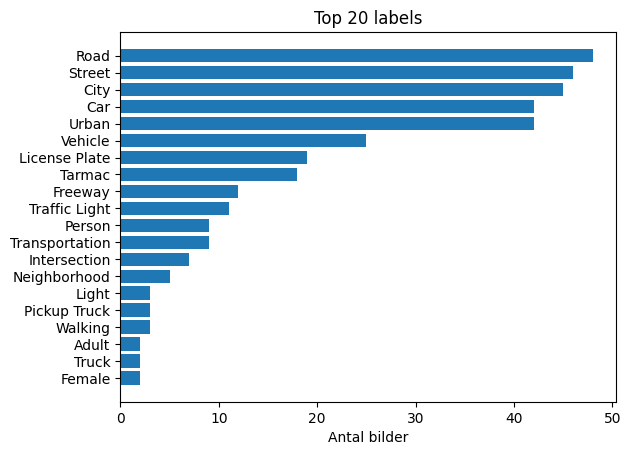

In [69]:
top_20 = df_98["label"].value_counts().head(20).sort_values()

plt.barh(top_20.index, top_20.values)
plt.xlabel("Antal bilder")
plt.title("Top 20 labels")

Här under kollar jag nu totala antalet av labels över samtliga bilder

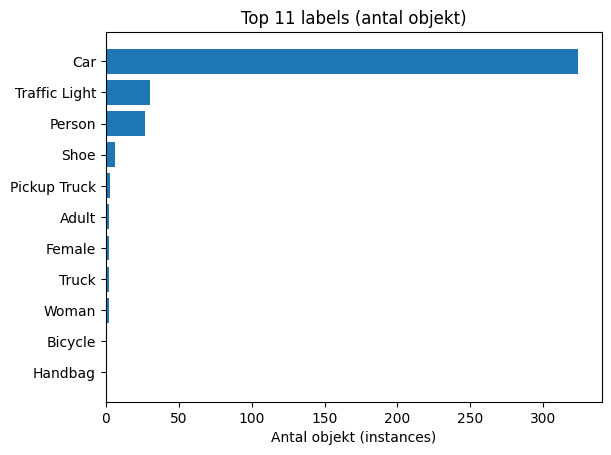

In [70]:
import matplotlib.pyplot as plt

top_11 = (
    df_98
    .groupby("label")["instances"]
    .sum()
    .sort_values(ascending=False)
    .head(11)
)

plt.figure()
plt.barh(top_11.index, top_11.values)
plt.xlabel("Antal objekt (instances)")
plt.title("Top 11 labels (antal objekt)")
plt.gca().invert_yaxis()
plt.show()

Eftersom att car är så pass störra än de andra väljer jag att göra en graf med de andra för att se fördelningen där.

In [71]:
top_10_no1 = top_11.iloc[1:]

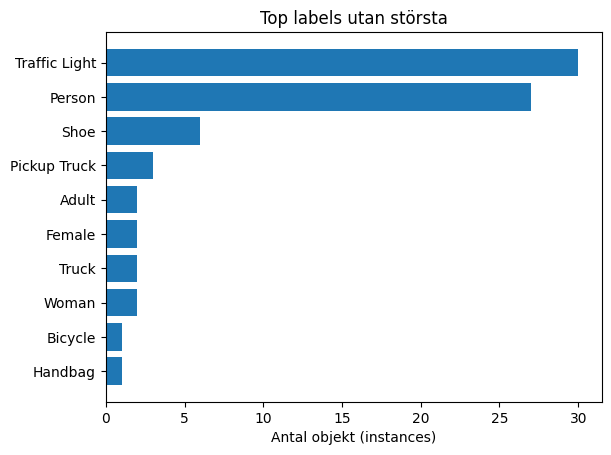

In [72]:
plt.figure()
plt.barh(top_10_no1.index, top_10_no1.values)
plt.xlabel("Antal objekt (instances)")
plt.title("Top labels utan största")
plt.gca().invert_yaxis()
plt.show()

Och så avslutar jag med ett litet fint pajdiagram som visar på top 2-6 för det är ju kul med pajdiagram

In [39]:
top_5 = top_11.iloc[1:6]

(np.float64(-1.0999907177800003),
 np.float64(1.099993787880706),
 np.float64(-1.0999988809185326),
 np.float64(1.0999999467104062))

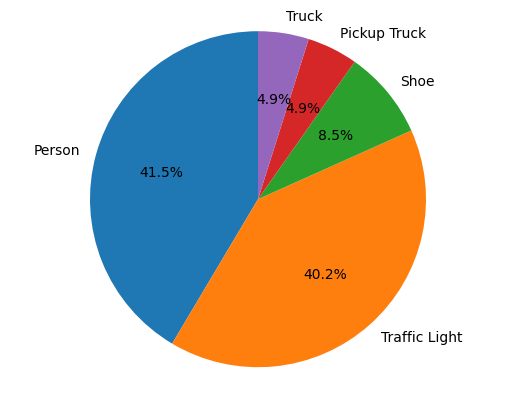

In [42]:
plt.pie(
    top_5.values,
    labels=top_5.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.axis("equal")

Så vad jag kan säga från mina bilder så är ju Car den label som är klart störst, vilket inte är konstigt då de bilder jag kollat på är från bilkameror. 
Men jag tyckte det var intressant att den registrerade skor som nummer 4 men borde inte alla personer den sett haft 2 par skor på sig? Det får ju en att fundera ^^
Skämt och sido så var det inget konstigt den registrerade med säkerhet på 98.5 procent. 